# Superstore Sales Data Visualization

## DevSphere Internship Program — Week 2

### Objective
Analyze the Superstore dataset using Python, Pandas, Matplotlib, and Seaborn to create meaningful visualizations and identify important business insights.

### Visualizations
- Bar Chart
- Line Chart
- Pie Chart

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
df = pd.read_csv("../data/superstore.csv", encoding="latin1")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [13]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (9994, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [14]:
print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null  

In [15]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values by column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date columns converted successfully.")
print(df[["Order Date", "Ship Date"]].dtypes)

Date columns converted successfully.
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


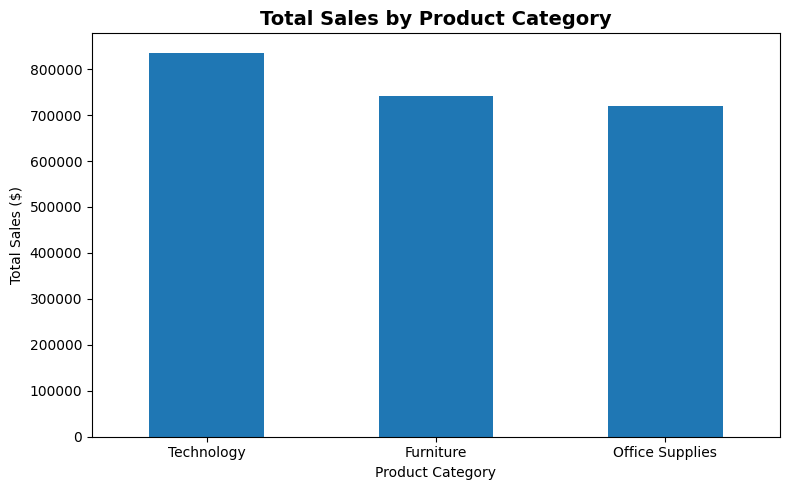

In [17]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("Sales by Category:")
print(category_sales)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Sales by Year:
Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


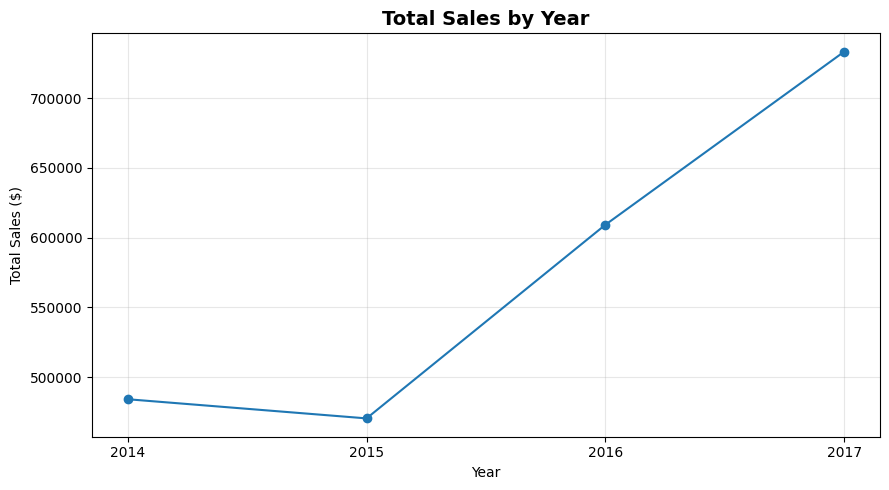

In [18]:
yearly_sales = df.groupby(df["Order Date"].dt.year)["Sales"].sum()

print("Sales by Year:")
print(yearly_sales)

plt.figure(figsize=(9, 5))

yearly_sales.plot(kind="line", marker="o")

plt.title("Total Sales by Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(yearly_sales.index)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

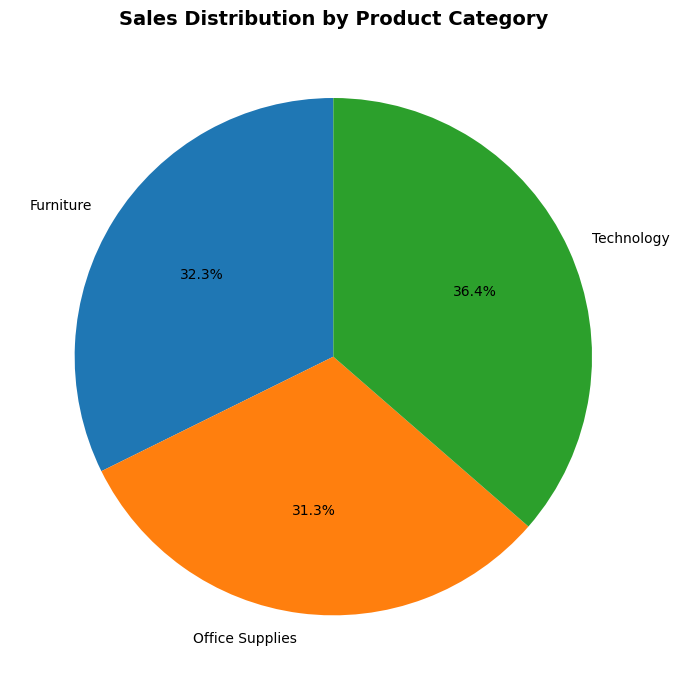

In [19]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7, 7))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Product Category", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [20]:
# Calculate key business insights

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

worst_category = category_sales.idxmin()
worst_category_sales = category_sales.min()

best_year = yearly_sales.idxmax()
best_year_sales = yearly_sales.max()

print("KEY BUSINESS INSIGHTS")
print("-" * 40)

print(f"Highest-selling category: {best_category}")
print(f"Sales: ${best_category_sales:,.2f}")

print(f"\nLowest-selling category: {worst_category}")
print(f"Sales: ${worst_category_sales:,.2f}")

print(f"\nHighest-sales year: {best_year}")
print(f"Sales: ${best_year_sales:,.2f}")

KEY BUSINESS INSIGHTS
----------------------------------------
Highest-selling category: Technology
Sales: $836,154.03

Lowest-selling category: Office Supplies
Sales: $719,047.03

Highest-sales year: 2017
Sales: $733,215.26


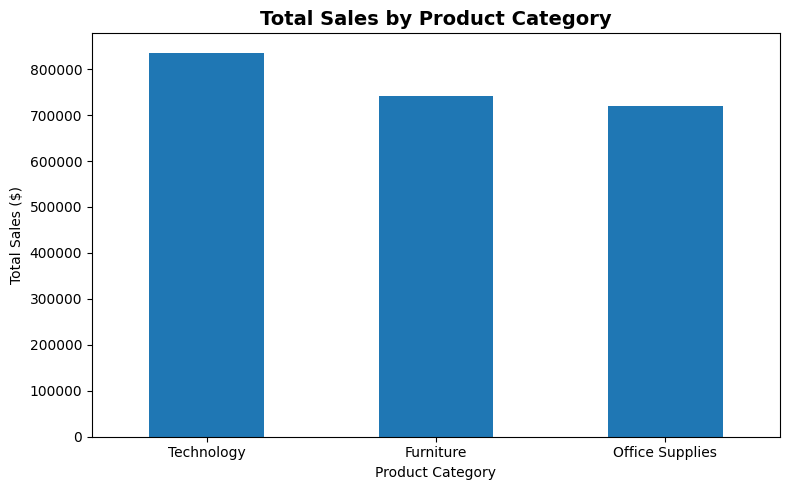

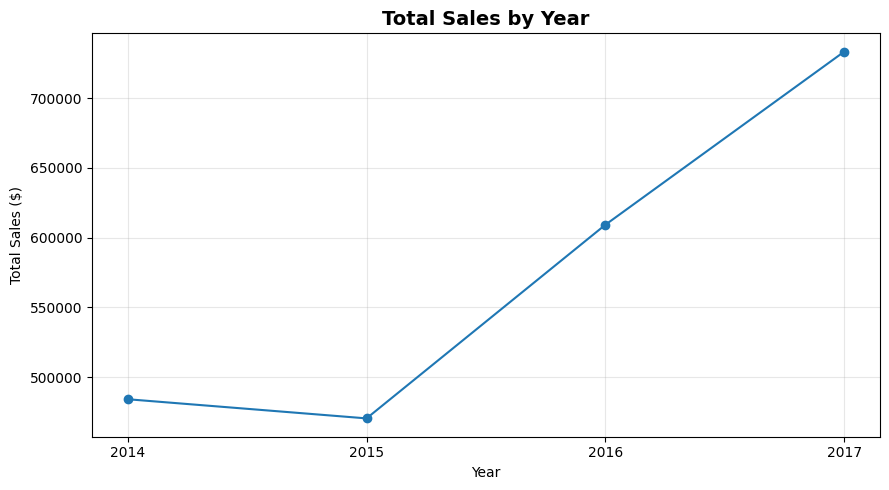

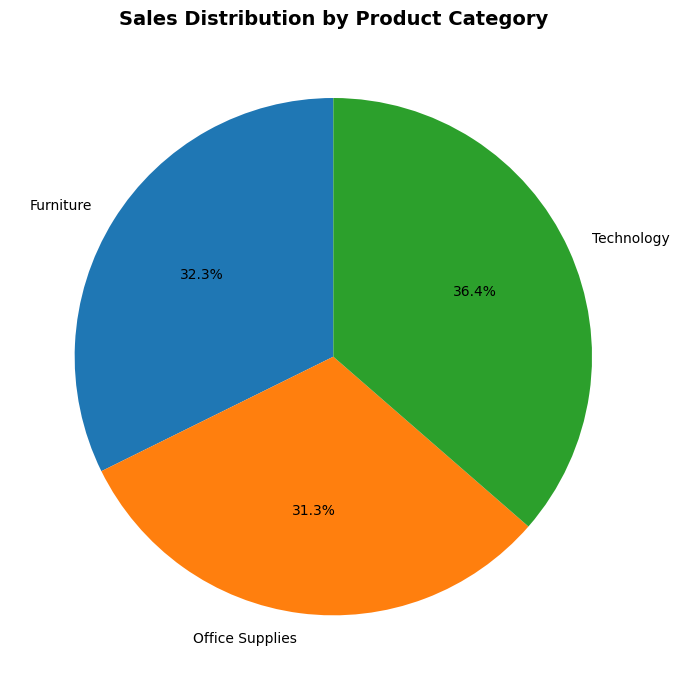

All 3 charts saved successfully!


In [21]:
import os

os.makedirs("../outputs/charts", exist_ok=True)

# 1. Bar Chart
plt.figure(figsize=(8, 5))
category_sales.sort_values(ascending=False).plot(kind="bar")
plt.title("Total Sales by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/charts/sales_by_category_bar.png", dpi=300)
plt.show()

# 2. Line Chart
plt.figure(figsize=(9, 5))
yearly_sales.plot(kind="line", marker="o")
plt.title("Total Sales by Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(yearly_sales.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/charts/sales_by_year_line.png", dpi=300)
plt.show()

# 3. Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Distribution by Product Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/charts/sales_distribution_pie.png", dpi=300)
plt.show()

print("All 3 charts saved successfully!")

## Key Visualization Insights

### 1. Sales by Product Category
The bar chart compares total sales across the three main product categories. It helps identify which category contributes the most to overall sales.

### 2. Sales Trend Over Time
The line chart shows how total sales changed across different years. This makes it easier to identify overall growth or decline in sales performance.

### 3. Sales Distribution
The pie chart shows the percentage contribution of each product category to total sales. It provides a clear view of the overall sales composition.

### Business Value
These visualizations help businesses understand sales performance, compare product categories, identify trends, and support data-driven decision-making.

In [22]:
print("FINAL DATASET SUMMARY")
print("-" * 40)

print(f"Total records: {len(df):,}")
print(f"Total sales: ${df['Sales'].sum():,.2f}")
print(f"Total profit: ${df['Profit'].sum():,.2f}")
print(f"Total quantity sold: {df['Quantity'].sum():,}")
print(f"Number of categories: {df['Category'].nunique()}")
print(f"Number of regions: {df['Region'].nunique()}")

FINAL DATASET SUMMARY
----------------------------------------
Total records: 9,994
Total sales: $2,297,200.86
Total profit: $286,397.02
Total quantity sold: 37,873
Number of categories: 3
Number of regions: 4


In [23]:
# Category performance summary

category_summary = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

category_summary

,Total_Sales,Total_Profit,Total_Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


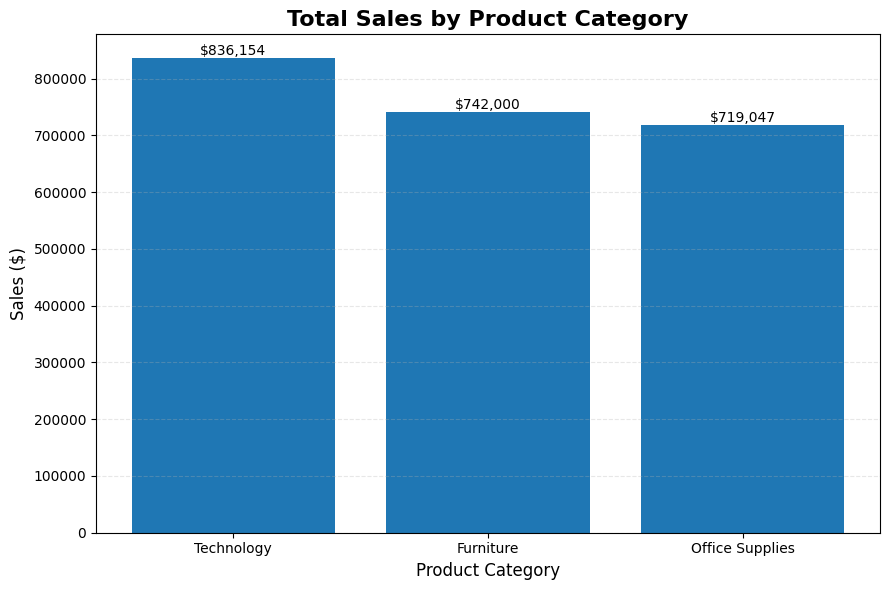

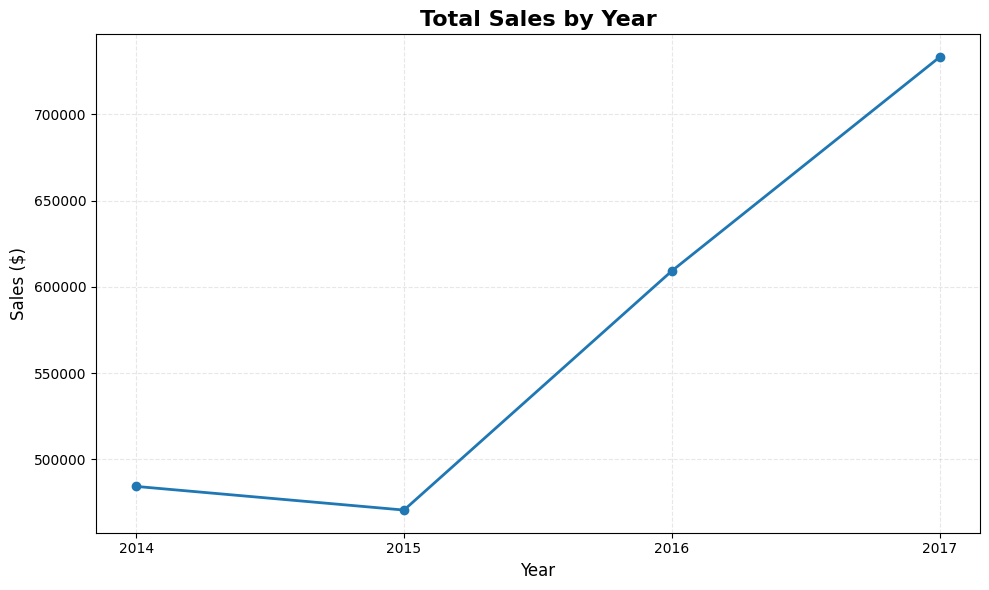

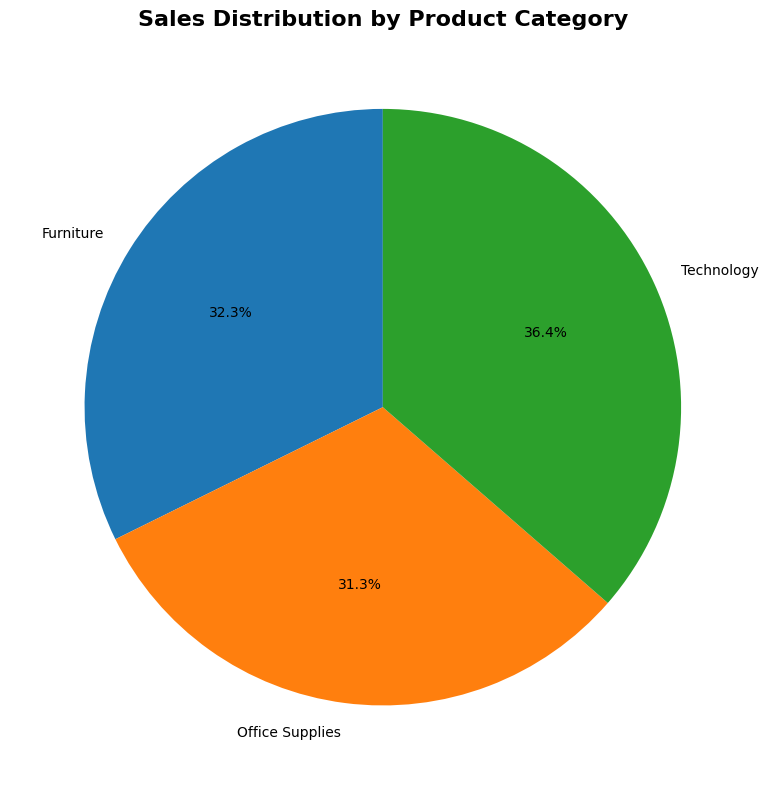

All professional charts saved successfully.


In [24]:
import os

os.makedirs("../outputs/charts", exist_ok=True)

# -----------------------------
# 1. BAR CHART
# -----------------------------

plt.figure(figsize=(9, 6))

category_sales_sorted = category_sales.sort_values(ascending=False)

bars = plt.bar(
    category_sales_sorted.index,
    category_sales_sorted.values
)

plt.title("Total Sales by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sales_by_category_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 2. LINE CHART
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Total Sales by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)

plt.xticks(yearly_sales.index)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sales_by_year_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 3. PIE CHART
# -----------------------------

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Sales Distribution by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sales_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("All professional charts saved successfully.")